In [2]:
# ============================================================
# PRODIGY benchmarking with TRUE ΔH labels
# - PDB IDs taken from PRODIGY CSV
# - ESM OFF
# - Same feature construction as training
# ============================================================

import os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT loading will fail:", e)
    torch = None

# ---------------------------
# PATHS
# ---------------------------
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TARGETS    = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"
SASA_PATH  = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/all_pdb_sasa.txt"

MODEL_PATH = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model.joblib"
PRODIGY_CSV = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/benchmarking/prodigy/elife-07454-supp2-v4.csv"

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

# ---------------------------
# Helpers
# ---------------------------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            ids.append(normalize_pdb_id(s.split()[0]))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols:
            return k
    raise ValueError("No ID column detected")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID")[FEATURE_COLS].mean()
    return df.sort_index()

def to_1d_numpy(x):
    if torch is not None and isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x, dtype=np.float64)
    return x.reshape(-1)

def load_pt_vector(feat_dir, pid):
    p = Path(feat_dir) / f"{pid}_mGLI.pt"
    if not p.exists():
        raise FileNotFoundError(pid)
    obj = torch.load(p, map_location="cpu")
    return to_1d_numpy(obj)

def load_targets_deltaH(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    df["JOIN_ID"] = df["pdb_id"].apply(normalize_pdb_id)
    return df.set_index("JOIN_ID")[["delta_H"]]

def load_sasa_table(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["JOIN_ID"] = df["pdb_id"].apply(normalize_pdb_id)
    df["total_sasa_kA2"] = df["total_sasa_A2"] / 1000.0
    return df.set_index("JOIN_ID")[["total_sasa_kA2"]]

def metrics(y, p):
    return dict(
        R2=r2_score(y, p),
        PearsonR=pearsonr(y, p)[0],
        Spearman=spearmanr(y, p)[0],
        MAE=mean_absolute_error(y, p),
        RMSE=np.sqrt(mean_squared_error(y, p)),
    )

# ---------------------------
# 1) Read PRODIGY CSV → PDB IDs
# ---------------------------
df_prod = pd.read_csv(PRODIGY_CSV)
pdb_ids = [normalize_pdb_id(x) for x in df_prod["PDB"]]

print(f"[PRODIGY] Total rows: {len(df_prod)}")
print(f"[PRODIGY] Example IDs: {pdb_ids[:10]}")

# ---------------------------
# 2) Filter by TXT allowlist
# ---------------------------
allowed = load_id_list(PDB_TXT)
ids_txt = sorted(set(i for i in pdb_ids if i in allowed))
print(f"[TXT] In allowlist: {len(ids_txt)} / {len(set(pdb_ids))}")

# ---------------------------
# 3) Load ΔH targets
# ---------------------------
df_y = load_targets_deltaH(TARGETS)
ids_lbl = [i for i in ids_txt if i in df_y.index]
print(f"[TARGETS] ΔH available: {len(ids_lbl)} / {len(ids_txt)}")

# ---------------------------
# 4) Load model
# ---------------------------
bundle = joblib.load(MODEL_PATH)
rf, et, hgb, meta = bundle["rf"], bundle["et"], bundle["hgb"], bundle["meta"]
pt_dim = bundle["pt_dim"]
extra_scalar_cols = bundle["extra_scalar_cols"]
use_sasa = bundle["use_sasa"]

# ---------------------------
# 5) Load CSV A/B
# ---------------------------
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

ids_csv = [i for i in ids_lbl if i in df_a.index and i in df_b.index]
print(f"[CSV] Present in A+B: {len(ids_csv)}")

# ---------------------------
# 6) Load PT
# ---------------------------
PT, ids_pt = [], []
for pid in ids_csv:
    v = load_pt_vector(FEAT_DIR, pid)
    if len(v) == pt_dim:
        PT.append(v)
        ids_pt.append(pid)

PT = np.vstack(PT)

# ---------------------------
# 7) Scalars (SASA + complex_count)
# ---------------------------
df_scalar = pd.DataFrame(index=ids_pt)

if use_sasa:
    df_sasa = load_sasa_table(SASA_PATH)
    df_scalar = df_scalar.join(df_sasa, how="left")

if "complex_count" in extra_scalar_cols:
    df_scalar["complex_count"] = 1.0

# ---------------------------
# 8) Build X
# ---------------------------
A = df_a.loc[ids_pt, FEATURE_COLS].values
B = df_b.loc[ids_pt, FEATURE_COLS].values

SUM, DIFF = A + B, A - B
ADIFF, PROD = np.abs(DIFF), A * B
COS = ((A * B).sum(axis=1) /
       (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-8)).reshape(-1, 1)
RATIO = DIFF / (SUM + 1e-8)

X = np.hstack([
    A, B, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT,
    df_scalar[extra_scalar_cols].values
])

y = df_y.loc[ids_pt, "delta_H"].values

# ---------------------------
# 9) Predict
# ---------------------------
p_rf = rf.predict(X)
p_et = et.predict(X)
p_hgb = hgb.predict(X)
p_bl3 = (p_rf + p_et + p_hgb) / 3.0

meta_X = np.column_stack([
    p_rf, p_et, p_hgb, p_bl3,
    p_rf - p_et, p_rf - p_hgb, p_et - p_hgb
])
p_stack = meta.predict(meta_X)

# ---------------------------
# 10) Metrics
# ---------------------------
for name, p in {
    "RF": p_rf,
    "ET": p_et,
    "HGB": p_hgb,
    "Blend3": p_bl3,
    "Stack": p_stack,
}.items():
    print(name, metrics(y, p))

# ---------------------------
# 11) Final evaluation table
# ---------------------------
df_eval = pd.DataFrame({
    "JOIN_ID": ids_pt,
    "delta_H": y,
    "pred_rf": p_rf,
    "pred_et": p_et,
    "pred_hgb": p_hgb,
    "pred_blend3": p_bl3,
    "pred_stack": p_stack,
}).set_index("JOIN_ID").sort_index()

print("\n[Eval head]")
print(df_eval.head())


[PRODIGY] Total rows: 81
[PRODIGY] Example IDs: ['1a2k', '1acb', '1ak4', '1akj', '1atn', '1avz', '1b6c', '1bj1', '1buh', '1bvk']
[TXT] In allowlist: 60 / 81
[TARGETS] ΔH available: 60 / 60
[CSV] Present in A+B: 60


/tmp/ipykernel_3790937/3483083019.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(p, map_location="cpu")


RF {'R2': 0.7826707592694444, 'PearsonR': 0.9410317014240527, 'Spearman': 0.9311326915693201, 'MAE': 5.146080047917442, 'RMSE': 6.931456962612954}
ET {'R2': 0.8766649577716139, 'PearsonR': 0.9438125468586123, 'Spearman': 0.9227969269705077, 'MAE': 2.871336608333322, 'RMSE': 5.22166123942743}
HGB {'R2': 0.24730924156770429, 'PearsonR': 0.7902609281124546, 'Spearman': 0.8134039095520955, 'MAE': 9.516578371369516, 'RMSE': 12.899525684058133}
Blend3 {'R2': 0.7230683620547788, 'PearsonR': 0.9340619260918824, 'Spearman': 0.9253810139961397, 'MAE': 5.684033984332073, 'RMSE': 7.824412475701118}
Stack {'R2': 0.6332110240698843, 'PearsonR': 0.894048730967689, 'Spearman': 0.8843968380519797, 'MAE': 6.946118662502409, 'RMSE': 9.0047899514208}

[Eval head]
         delta_H    pred_rf    pred_et   pred_hgb  pred_blend3  pred_stack
JOIN_ID                                                                   
1acb      -69.74 -67.159999 -69.029765 -57.838389   -64.676051  -61.730357
1ak4      -47.21 -47.

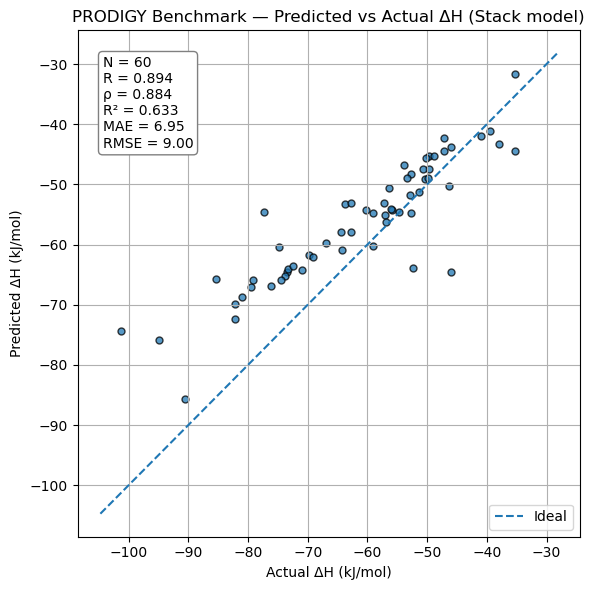

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("PRODIGY Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


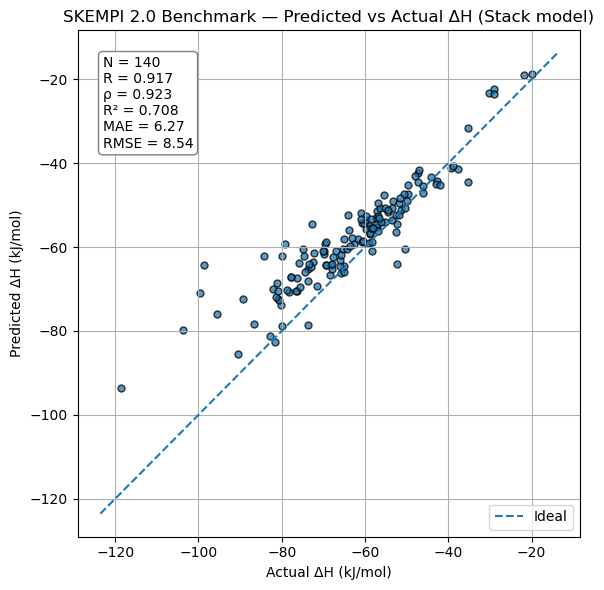

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("SKEMPI 2.0 Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


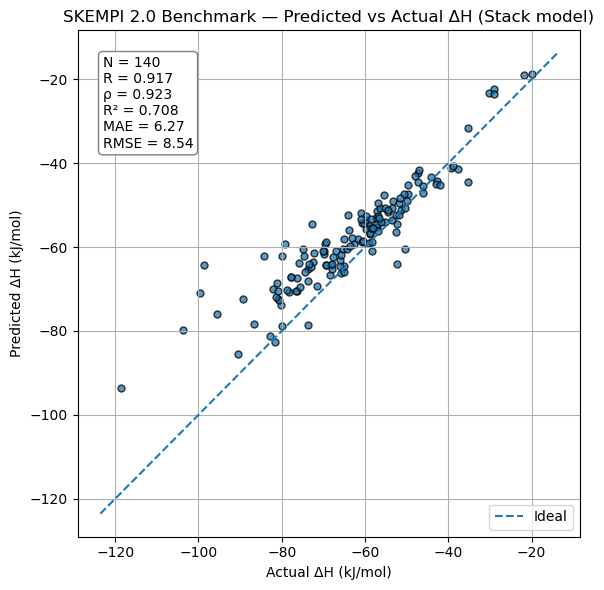

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("SKEMPI 2.0 Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


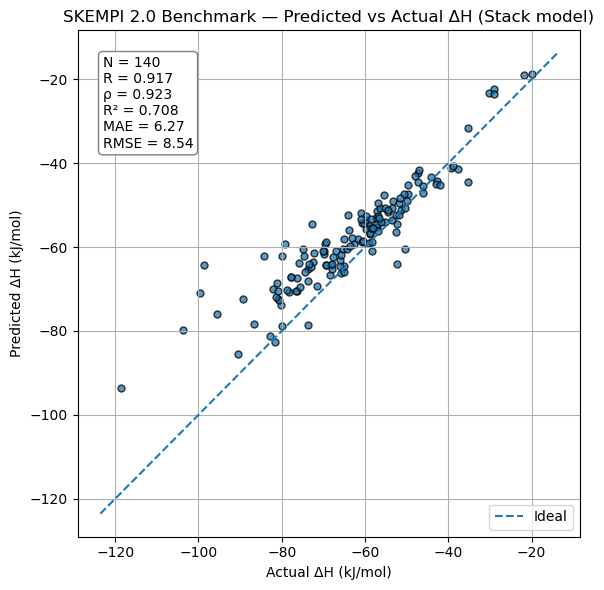

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("SKEMPI 2.0 Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
